[START]WR AFE 0 REG 52 V 16896[RESULT]Executing command 8 ... CMD Write AFE0 REG52 success ... Command Complete, return code 0[END] 
[START]WR AFE 0 REG 4 V 24[RESULT]Executing command 8 ... CMD Write AFE0 REG4 success ... Command Complete, return code 0[END] 
[START]WR AFE 0 REG 51 V 0[RESULT]Executing command 8 ... CMD Write AFE0 REG51 success ... Command Complete, return code 0[END] 
[START]WR AFE 0 VGAIN V 2318[RESULT]Executing command 8 ... CMD Write AFE0 VGAIN success ... Command Complete, return code 0[END] 


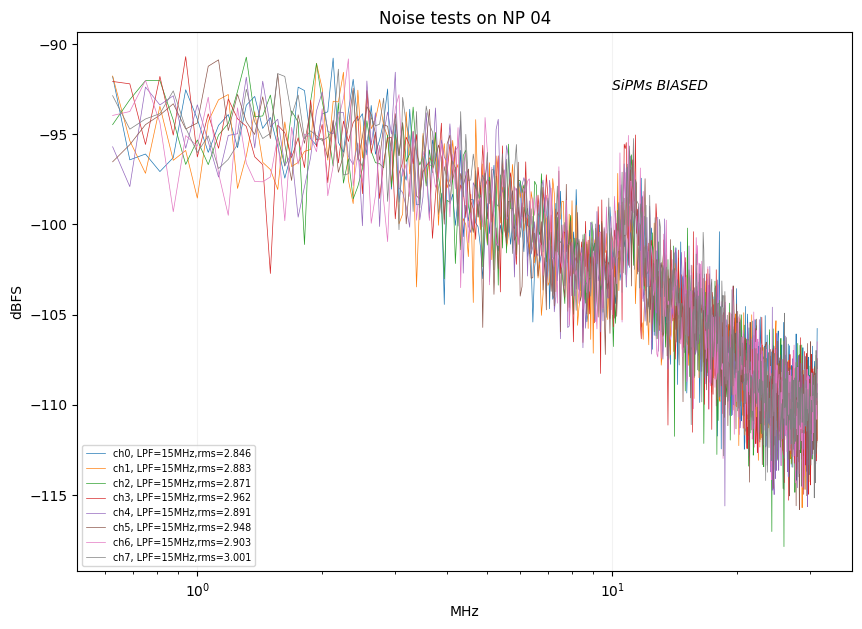

In [3]:
import socket
import struct
from time import sleep
import time
import unicodedata

# from oei import *
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import numpy as np
import warnings
import time


"""

"""



class OEI(object):

    def __init__(self,ipaddr,port=2001):
        self.sock = socket.socket(socket.AF_INET,socket.SOCK_DGRAM)
        self.target = (ipaddr,port)

    def read_reg(self,addr,size): 
        cmd = struct.pack("BB",0x00,size) 
        cmd += struct.pack("Q",addr)
        self.sock.sendto(cmd,self.target)
        d,a = self.sock.recvfrom(2+(8*size))
        return struct.unpack(f"<BB{size}Q",d) 

    def write_reg(self,addr,data): 
        cmd = struct.pack("BB",1,len(data)) 
        cmd += struct.pack("Q",addr)
        for i in data:
            cmd += struct.pack("Q",i)
        self.sock.sendto(cmd,self.target)

    def read_fifo(self,addr,size):
        cmd = struct.pack("BB",0x08,size) 
        cmd += struct.pack("Q",addr)
        self.sock.sendto(cmd,self.target)
        d,a = self.sock.recvfrom(2+(8*size))
        return struct.unpack(f"<BB{size}Q",d)

    def write_fifo(self,addr,data): 
        cmd = struct.pack("BB",0x09,len(data)) 
        cmd += struct.pack("Q",addr)
        for i in data:
            cmd += struct.pack("Q",i)
        self.sock.sendto(cmd,self.target)

    def close(self):
        self.sock.close()




def remove_control_characters(s):
    return "".join(ch for ch in s if unicodedata.category(ch)[0]!="C")
    
class Command:
    def __init__(self,ip, cmd_string, get_response=True):
        self.device = OEI(ip)
        self.cmd_bytes = [ord(ch) for ch in cmd_string]
        self.cmd_bytes.append(0x0d)
        for i in range(0, len(self.cmd_bytes), 50):
            self.device.write_fifo(0x90000000, self.cmd_bytes[i*50:(i+1)*50])
        self.response = self.get_response_data() if get_response else None
        self.device.close()
        
    def get_response_data(self, fifo_address=0x90000000, chunk_size=50, timeout=0.007):
        """
        Reads response data from the hardware FIFO, interpreting protocol markers.
        """
        response = ""
        more = 40  # Number of attempts to read data
        while more > 0:
            try:
                # Read chunk from the FIFO
                response_bytes = self.device.read_fifo(fifo_address, chunk_size)
            except TimeoutError:
                break  # Exit loop on timeout

            for b in response_bytes[2:]:
                if b == 255:  # End-of-response marker
                    break
                elif b in (1, 2, 3):  # Protocol markers
                    response += f"[{['START', 'RESULT', 'END'][b-1]}]"
                elif chr(b).isprintable():  # Append printable characters
                    more = 40  # Reset counter if valid data is received
                    response += chr(b)
            sleep(timeout)  # Allow hardware to fill the FIFO
            more -= 1  # Decrement retry counter

        response += chr(0)  # Append null termination
        print(response)  # Debugging
        return remove_control_characters(response)
        
# read_bias=[Command(f'10.73.137.{100+i}', 'RD VM ALL') for i in [4,5,7,9,11,12,13]]




class readwave:
    def __init__(self, ep=112, afe=4, ch=4,plot=False):
        thing = OEI(f"10.73.137.{ep}")
        thing.write_reg(0x2000,[1234])
        wf=[]
        for i in range (20):
            doutrec = thing.read_reg(0x40000000+(0x100000 * afe)+(0x10000 * ch)+i*50,50)[2:]
            for word in doutrec:
                wf.append(word)
        x = np.linspace(0.0, len(wf) * 16e-9, num=len(wf))
        if plot:
            plt.figure()
            plt.plot(x,wf,linewidth=0.6,label=f' \t rms={np.round(np.mean(wf),2)}')
            plt.show()
        self.wf=np.array(wf)
        self.afe=afe
        self.ch=ch
        self.ep=ep
        thing.close()
class fft:
    def __init__(self, sig, dt=16e-9, plot=False):
        np.seterr(divide = 'ignore')
        if dt is None:
            dt = 1
            t = np.arange(0, sig.shape[-1])
            xLabel = "samples"
        else:
            t = np.arange(0, sig.shape[-1]) * dt
            xLabel = "freq [Hz]"
        if sig.shape[0] % 2 != 0:
            warnings.warn("signal preferred to be even in size, autoFixing it...")
            t = t[:-1]
            sig = sig[:-1]
        sigFFT = np.fft.fft(sig) / t.shape[0]
        freq = np.fft.fftfreq(t.shape[0], d=dt)
        firstNegInd = np.argmax(freq < 0)
        freqAxisPos = freq[:firstNegInd]
        sigFFTPos = 2 * sigFFT[:firstNegInd]
        if plot:
            plt.figure()
            plt.plot(freqAxisPos, 20*np.log10(np.abs(sigFFTPos)/2**14))
            plt.ylim([-140, -80])
            plt.xscale("log")
            plt.xlabel(xLabel)
            plt.ylabel("U.A.")
            plt.title("Analytic FFT plot")
            plt.show()
        self.x = freqAxisPos /10e5
        self.y = 20*np.log10(np.abs(sigFFTPos)/2**14)
#wf=readwave(plot=True).wf
#f=fft   (wf,dt=None,plot=True)    
class mean_fft:
    def __init__(self, data,label,plot=False):
        np.seterr(divide = 'ignore')
        fft_list_x=[]
        fft_list_y=[]
        mean_list=[]
        std_list=[]
        for k in range(len(data)):
            fft_list_x.append(fft(data[k]).x)
            fft_list_y.append(fft(data[k]).y)
            std_list.append(np.std(data[k],axis=0))
        self.x=np.mean(fft_list_x,axis=0)
        self.y=np.mean(fft_list_y,axis=0)
        self.stdx=np.round(np.mean(std_list,axis=0),3)
        if plot:
            plt.rcParams["figure.figsize"] = (10,7)
            plt.figure()
            plt.plot(self.x,self.y,linewidth=1,label=f'{label} \t rms={np.round(self.stdx,2)}'.expandtabs())
            plt.ylim([min(self.y)-10, -80])
            #plt.xscale("log")
            # plt.xlim([0.2, 3])
            plt.legend()
            plt.ylabel("dBFS")
            plt.xlabel("MHz")
            plt.title("FFT")
            plt.tight_layout()
def main():
    np.seterr(divide = 'ignore')
    plt.rcParams["figure.figsize"] = (10,7)
    plt.figure()
    AFE=[0,]
    ammount=8
    ep=104
    Command(f'10.73.137.{ep}',f'WR AFE {AFE[0]} REG 52 V 16896')
    Command(f'10.73.137.{ep}',f'WR AFE {AFE[0]} REG 4 V 24')
    Command(f'10.73.137.{ep}',f'WR AFE {AFE[0]} REG 51 V 0')
    Command(f'10.73.137.{ep}',f'WR AFE {AFE[0]} VGAIN V 2318')
    for j in [104]:
        for k in AFE:
            for l in range(8):
                # progress=trange(l, unit='channels',desc = f'Reading ch{l} from endpoint {j}:')
                d = [readwave(ep=j, ch=l,afe=AFE[k]).wf for _ in range(ammount) ]
                mfft=mean_fft(d,label=f'endpoint {j}')
                plt.plot(mfft.x[10:],mfft.y[10:],linewidth=0.5,label=f'ch{k*10+l}, LPF=15MHz,rms={mfft.stdx}'.expandtabs())
                # progress.update(1)
    plt.xscale("log")
    #plt.xlim([0.8, 0.9])
    plt.legend(ncol=1,loc=3,fontsize = 'x-small')
    plt.ylabel("dBFS")
    plt.xlabel("MHz")
    #plt.title(f"Noise tests on APA 1 ch {Channel+AFE[0]*8} M7 disconnected, ch0 of M8 isolated")
    plt.title(f"Noise tests on NP 04")
    plt.grid(axis='x',color="0.95")
    # plt.text(1.5, -108, 'Integrators On', style='italic')
    # plt.text(1.5, -109, 'Offset=2200', style='italic')
    # plt.text(1.5, -110, 'VGAIN=2318', style='italic')
    plt.text(10, -92.5, 'SiPMs BIASED', style='italic')
    # plt.tight_layout()
    # plt.savefig(f'Noise tests ch{Channel+AFE*8}.png',dpi=400)
if __name__ == "__main__":
    main()





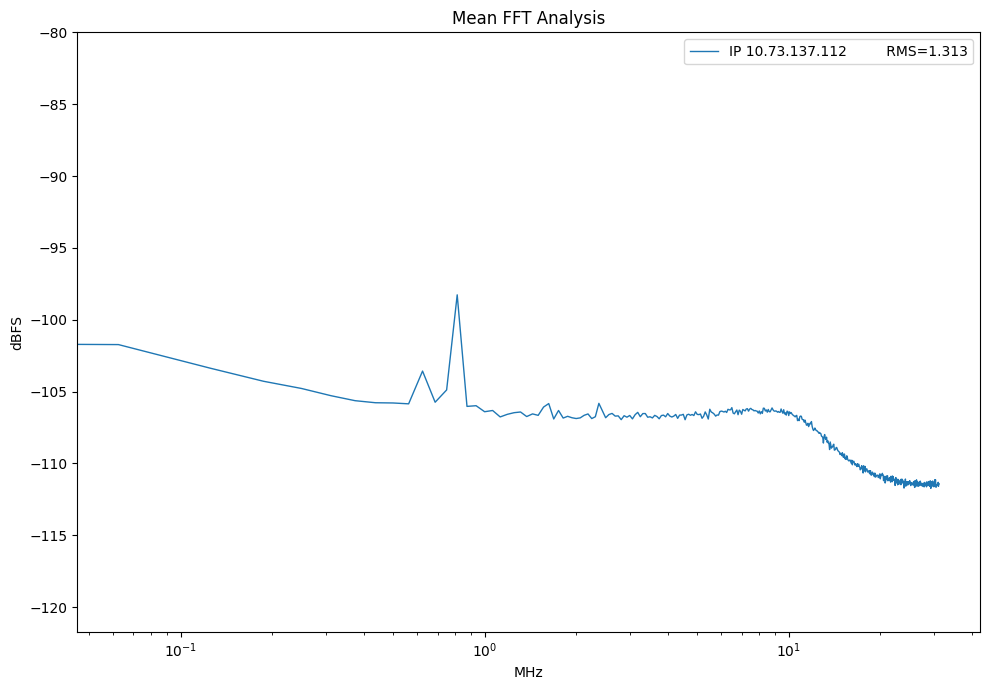

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ivtools import Daphne  # Replace with the actual name of the daphne module

def remove_control_characters(s):
    return "".join(ch for ch in s if unicodedata.category(ch)[0] != "C")

class Command:
    def __init__(self, ip, cmd_string, get_response=True):
        self.device = Daphne(ip)
        self.cmd_bytes = [ord(ch) for ch in cmd_string]
        self.cmd_bytes.append(0x0D)
        for i in range(0, len(self.cmd_bytes), 50):
            self.device.write_fifo(0x90000000, self.cmd_bytes[i:i + 50])
        self.response = self.get_response_data() if get_response else None
        self.device.close()

    def get_response_data(self, fifo_address=0x90000000, chunk_size=50, timeout=0.007):
        response = ""
        more = 40  # Number of attempts to read data
        while more > 0:
            try:
                response_bytes = self.device.read_fifo(fifo_address, chunk_size)
            except TimeoutError:
                print("Timeout: Failed to read response from FIFO.")
                break

            for b in response_bytes[2:]:
                if b == 255:  # End-of-response marker
                    break
                elif chr(b).isprintable():
                    response += chr(b)
            sleep(timeout)
            more -= 1

        response = remove_control_characters(response)
        if not response:
            print(f"Warning: Empty response for command '{cmd_string}'.")
        return response


class readwave:
    def __init__(self, ip, afe=4, ch=4, samples=1000, plot=False):
        thing = Daphne(ip)
        thing.write_reg(0x2000, [1234])  # Trigger spy buffers
        wf = []

        try:
            for i in range(samples // 50):
                addr = 0x40000000 + (0x100000 * afe) + (0x10000 * ch) + (i * 50)
                doutrec = thing.read_reg(addr, 50)[2:]
                wf.extend(doutrec)
        except Exception as e:
            print(f"Error reading waveform for AFE {afe}, Channel {ch}, IP {ip}: {e}")
        finally:
            thing.close()

        if not wf or all(v == 0 for v in wf):
            print(f"Warning: Empty or zero waveform for AFE {afe}, Channel {ch}, IP {ip}")

        self.wf = np.array(wf)
        self.afe = afe
        self.ch = ch
        self.ip = ip

        if plot:
            self._plot_waveform()

    def _plot_waveform(self):
        """
        Plots the waveform data.
        """
        time_axis = np.linspace(0.0, len(self.wf) * 16e-9, num=len(self.wf))
        plt.figure(figsize=(10, 5))
        plt.plot(time_axis, self.wf, linewidth=0.6, label=f"AFE {self.afe} CH {self.ch}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.title(f"Waveform for AFE {self.afe}, Channel {self.ch}")
        plt.legend()
        plt.grid()
        plt.show()


class fft:
    def __init__(self, sig, dt=16e-9, plot=False):
        np.seterr(divide="ignore")
        t = np.arange(0, sig.shape[-1]) * dt
        sigFFT = np.fft.fft(sig) / t.shape[0]
        freq = np.fft.fftfreq(t.shape[0], d=dt)
        firstNegInd = np.argmax(freq < 0)
        freqAxisPos = freq[:firstNegInd]
        sigFFTPos = 2 * sigFFT[:firstNegInd]

        self.x = freqAxisPos / 1e6  # Convert to MHz
        self.y = 20 * np.log10(np.abs(sigFFTPos) / 2**14)

        if plot:
            self._plot_fft()

    def _plot_fft(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.x, self.y, linewidth=0.6)
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("Magnitude (dBFS)")
        plt.title("FFT Analysis")
        plt.ylim([-140, -80])
        plt.xscale("log")
        plt.grid()
        plt.show()


class mean_fft:
    def __init__(self, data, label, plot=False):
        fft_list_x = []
        fft_list_y = []
        std_list = []

        for k, signal in enumerate(data):
            if not signal.any():
                print(f"Skipping empty or zero signal at index {k}.")
                continue

            fft_result = fft(signal).y
            fft_freqs = fft(signal).x

            fft_list_x.append(fft_freqs)
            fft_list_y.append(fft_result)
            std_list.append(np.std(signal))

        if not fft_list_x or not fft_list_y:
            raise ValueError("No valid FFT data to compute mean.")

        self.x = np.mean(fft_list_x, axis=0)
        self.y = np.mean(fft_list_y, axis=0)
        self.stdx = np.round(np.mean(std_list, axis=0), 3)

        if plot:
            self._plot_mean_fft(label)

    def _plot_mean_fft(self, label):
        plt.figure(figsize=(10, 7))
        plt.plot(self.x, self.y, linewidth=1, label=f"{label} \t RMS={self.stdx}".expandtabs())
        plt.ylim([min(self.y) - 10, -80])
        plt.xscale("log")
        plt.ylabel("dBFS")
        plt.xlabel("MHz")
        plt.title("Mean FFT Analysis")
        plt.legend()
        plt.tight_layout()
        plt.show()


# Example Usage
if __name__ == "__main__":
    AFE = 4
    CHANNEL = 4
    SAMPLES = 1000
    IP = "10.73.137.112"
    REPEATS = 2000

    # Collect waveforms
    waveforms = [readwave(ip=IP, afe=AFE, ch=CHANNEL, samples=SAMPLES).wf for _ in range(REPEATS)]

    # Perform mean FFT analysis
    mean_fft_analysis = mean_fft(data=waveforms, label=f"IP {IP}", plot=True)

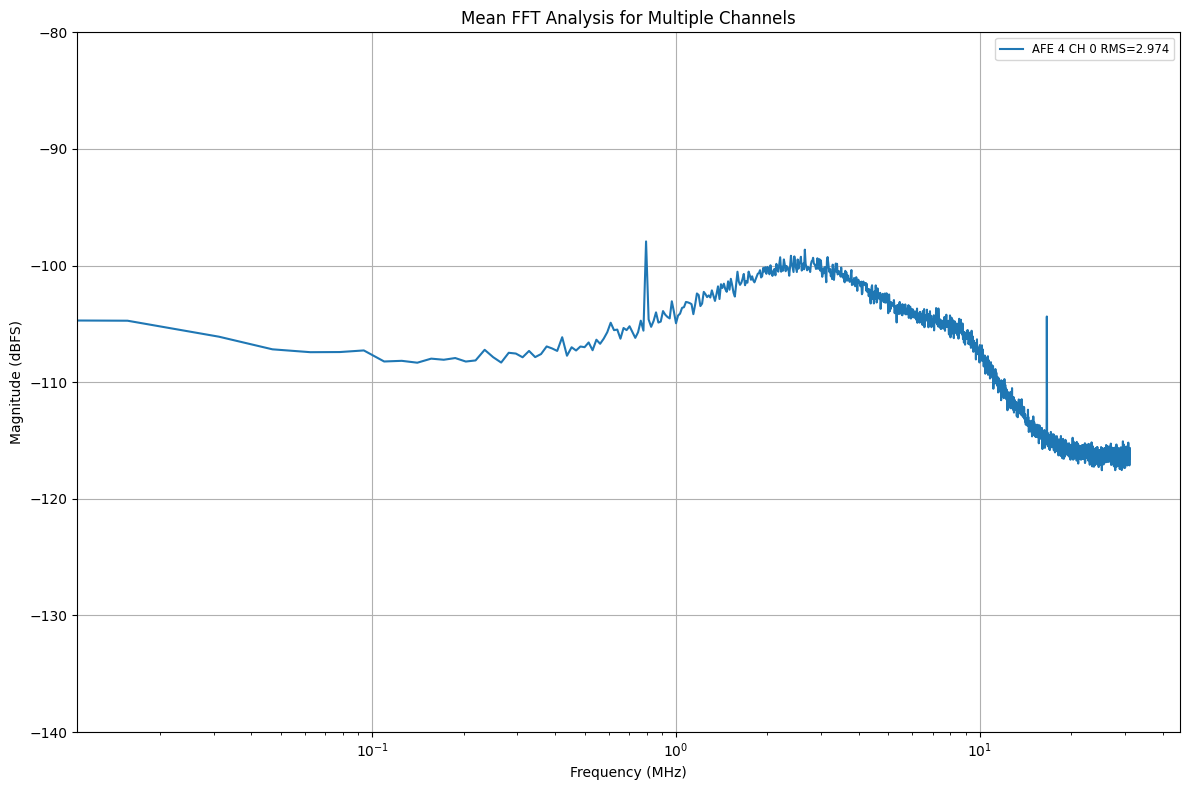

In [1]:
from ivtools import Daphne

if __name__ == "__main__":
    IP = "10.73.137.112"
    AFE = 4
    CHANNELS = [0]  # Channels to analyze
    SAMPLES = 4000
    REPEATS = 200

    device = Daphne(IP)

    # Compute mean FFTs for all channels
    mean_fft_results = device.compute_mean_fft_for_channels(
        afe=AFE, channels=CHANNELS, samples=SAMPLES, repeats=REPEATS, plot=True
    )

In [1]:
from ivtools import Daphne

if __name__ == "__main__":
    # List of IP addresses to compare
    IPS = ["10.73.137.112", "10.73.137.113"]
    AFE = 4
    CHANNEL = 3
    SAMPLES = 1000
    REPEATS = 20
    DT = 16e-9
    
    # Compare FFTs across multiple IPs
    fft_results = Daphne.compare_ffts_across_ips_and_channels(
        ips=IPS, afe=AFE, ch=CHANNEL, samples=SAMPLES, dt=DT, repeats=REPEATS, plot=True
    )

    # Access results for individual IPs
    for ip, (x, y, rms) in fft_results.items():
        print(f"IP {ip}:")
        print("Frequency (MHz):", x)
        print("Mean FFT Magnitude (dBFS):", y)
        print("RMS:", rms)

AttributeError: type object 'Daphne' has no attribute 'compare_ffts_across_ips'